# Feature Analysis v4 — CSIC 2010

**Versión:** v4  
**Notebook:** `csic2010_feature_analysis_v4.ipynb`  
**Base:** features de v3 (19 features) + 3 nuevas construidas en memoria  
**MLflow experiment:** `mlsec-model-a`

---

## Contexto

v3 llegó a Precision 0.713 con LightGBM. El análisis de FP mostró:

- **62.2% de los FP son GETs** (935 requests) — no atacables con features de content
- **37.8% son POSTs** (569 requests) — `content_pct_density` solo redujo 88

El cuello de botella son los 935 FP GET. Tienen URLs más largas que el tráfico normal GET,
pero sin ningún indicador de payload. La hipótesis es que la **estructura de la URL**
(profundidad del path, longitud de la query string) distingue mejor que la longitud total.

## Hipótesis

Las features de estructura de URL dan contexto diferente a `url_length`:

| Feature candidata | Qué mide | Hipótesis |
|---|---|---|
| `url_path_depth` | Número de `/` en el path (antes del `?`) | Los ataques de traversal y los scans tienen paths más profundos |
| `url_query_length` | Longitud de la query string (después del `?`) | Los ataques inyectan payloads en query params — queries más largas |
| `url_has_query` | Si la URL tiene `?` | Separa GETs con parámetros de GETs sin parámetros |

## Secciones

1. Análisis de subpoblación GET — correlación de features candidatas con el label
2. Distribución en FP GET vs ataques GET — ¿las features separan?
3. Selección de features
4. Build v4 dataset (22 features)
5. Entrenamiento de 4 modelos + MLflow tracking
6. Tabla comparativa v3 vs v4
7. Observaciones


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import tempfile, os
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, precision_recall_curve,
    f1_score, recall_score, precision_score,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

pd.set_option('display.max_columns', None)

# Project root — busca mkdocs.yml subiendo desde el CWD
_here = Path(os.path.abspath('')).resolve()
_root = _here
for _ in range(5):
    if (_root / 'mkdocs.yml').exists():
        break
    _root = _root.parent
PROJECT_ROOT = _root

RAW_PATH  = str(PROJECT_ROOT / 'data/raw/csic2010/csic_database.csv')
RANDOM_STATE = 42
MIN_RECALL   = 0.95
MIN_PREC     = 0.85

# Resultados v3 como baseline de comparación
V3_RESULTS = {
    'Logistic Regression': {'roc_auc': 0.777, 'recall': 0.977, 'precision': 0.417},
    'Random Forest':       {'roc_auc': 0.950, 'recall': 0.947, 'precision': 0.716},
    'XGBoost':             {'roc_auc': 0.948, 'recall': 0.958, 'precision': 0.649},
    'LightGBM':            {'roc_auc': 0.955, 'recall': 0.952, 'precision': 0.713},
}

# MLflow — path literal con espacio (SQLAlchemy NO decodifica %20, no encodear)
MLFLOW_DB  = str(PROJECT_ROOT / 'mlflow.db')
MLFLOW_URI = 'sqlite:////' + MLFLOW_DB.lstrip('/')
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment('mlsec-model-a')
print(f'Project root:        {PROJECT_ROOT}')
print(f'MLflow DB:           {MLFLOW_DB}')
print(f'MLflow tracking URI: {MLFLOW_URI}')
assert MLFLOW_DB in MLFLOW_URI, 'ERROR: el URI no contiene la ruta correcta'
print('MLflow configurado correctamente')


Project root:        /Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec
MLflow DB:           /Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec/mlflow.db
MLflow tracking URI: sqlite:////Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec/mlflow.db
MLflow configurado correctamente


## 1. Subpoblación GET — correlación de features candidatas

Analizamos las 3 features candidatas **exclusivamente en GETs** — donde la estructura
de la URL tiene significado real. Incluir POSTs diluiría la señal porque sus URLs
son estructuralmente distintas.


In [2]:
raw = pd.read_csv(RAW_PATH)
raw = raw.rename(columns={'classification': 'label'})

url    = raw['URL'].fillna('')
method = raw['Method'].str.upper()

# Construir features candidatas
url_path  = url.str.split('?').str[0]          # path: todo antes del ?
url_query = url.str.split('?').str[1].fillna('') # query: todo después del ?

raw['url_path_depth']   = url_path.str.count('/').astype('int16')
raw['url_query_length'] = url_query.str.len().astype('int32')
raw['url_has_query']    = url.str.contains('?', regex=False).astype('int8')

# Subpoblación GET
is_get = method == 'GET'
df_get = raw[is_get][['url_path_depth', 'url_query_length', 'url_has_query', 'label']].copy()

print(f'Total requests:    {len(raw)}')
print(f'GET requests:      {is_get.sum()}  ({is_get.mean():.1%})')
print(f'  GET normales:    {(df_get["label"]==0).sum()}')
print(f'  GET ataques:     {(df_get["label"]==1).sum()}')
print()
print('Correlación con label en subpoblación GET:')
print('-' * 45)
for col in ['url_path_depth', 'url_query_length', 'url_has_query']:
    corr = df_get[col].corr(df_get['label'])
    print(f'  {col:<22}  {corr:+.3f}')

# Correlación global (toda la población) para comparar
print()
print('Correlación con label en TODA la población (para comparar):')
print('-' * 45)
for col in ['url_path_depth', 'url_query_length', 'url_has_query']:
    corr = raw[col].corr(raw['label'])
    print(f'  {col:<22}  {corr:+.3f}')


Total requests:    61065
GET requests:      43088  (70.6%)
  GET normales:    28000
  GET ataques:     15088

Correlación con label en subpoblación GET:
---------------------------------------------
  url_path_depth          -0.318
  url_query_length        +0.297
  url_has_query           +0.341

Correlación con label en TODA la población (para comparar):
---------------------------------------------
  url_path_depth          -0.198
  url_query_length        +0.178
  url_has_query           +0.175


## 2. Distribución en FP GET vs ataques GET

Comparamos las 3 features entre:
- **Ataques GET** (label=1, method=GET) — los que el modelo debería detectar
- **Normal GET** (label=0, method=GET) — los que el modelo confunde con ataques

Si las distribuciones son distintas, el modelo tiene señal nueva para separarlos.


Estadísticas — subpoblación GET

url_path_depth
         Media   Ataque=  5.28  Normal=  5.79  ratio=0.91x
       Mediana   Ataque=  5.00  Normal=  6.00

url_query_length
         Media   Ataque= 84.03  Normal= 28.73  ratio=2.92x
       Mediana   Ataque= 48.00  Normal=  0.00

url_has_query
         Media   Ataque=  0.64  Normal=  0.29  ratio=2.23x
       Mediana   Ataque=  1.00  Normal=  0.00


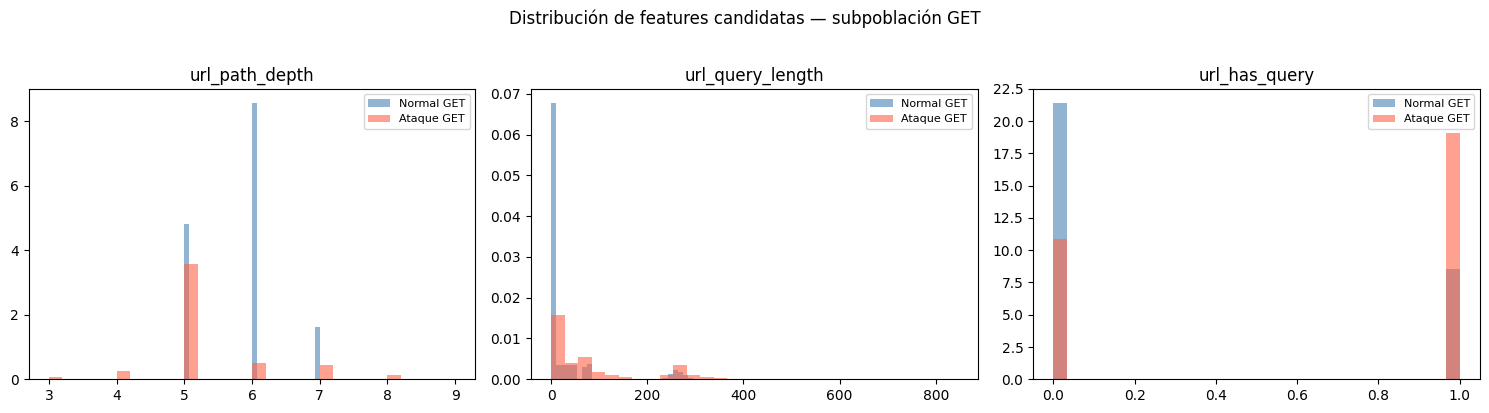

In [3]:
attack_get = df_get[df_get['label'] == 1]
normal_get = df_get[df_get['label'] == 0]

print('Estadísticas — subpoblación GET')
print('=' * 65)
for col in ['url_path_depth', 'url_query_length', 'url_has_query']:
    a_mean = attack_get[col].mean()
    n_mean = normal_get[col].mean()
    a_med  = attack_get[col].median()
    n_med  = normal_get[col].median()
    print(f'\n{col}')
    print(f'  {'Media':>12}   Ataque={a_mean:6.2f}  Normal={n_mean:6.2f}  ratio={a_mean/max(n_mean,0.001):.2f}x')
    print(f'  {'Mediana':>12}   Ataque={a_med:6.2f}  Normal={n_med:6.2f}')

# Plots de distribución
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['url_path_depth', 'url_query_length', 'url_has_query']):
    ax.hist(normal_get[col], bins=30, alpha=0.6, label='Normal GET', color='steelblue', density=True)
    ax.hist(attack_get[col], bins=30, alpha=0.6, label='Ataque GET', color='tomato', density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Distribución de features candidatas — subpoblación GET', y=1.02)
plt.tight_layout()
plt.show()


## 3. Selección de features

Decisión basada en correlación en subpoblación GET y diferencia de distribuciones.


In [4]:
print('Resumen de correlaciones GET — decisión de features:')
print('=' * 60)
candidatas = ['url_path_depth', 'url_query_length', 'url_has_query']
for col in candidatas:
    corr_get    = df_get[col].corr(df_get['label'])
    corr_global = raw[col].corr(raw['label'])
    print(f'{col:<22}  GET={corr_get:+.3f}  global={corr_global:+.3f}')
print()
print('Nota: correlación GET > global = señal real en la subpoblación relevante.')
print('Correlación global inflada/deflada por mezcla GET+POST = ruido estructural.')


Resumen de correlaciones GET — decisión de features:
url_path_depth          GET=-0.318  global=-0.198
url_query_length        GET=+0.297  global=+0.178
url_has_query           GET=+0.341  global=+0.175

Nota: correlación GET > global = señal real en la subpoblación relevante.
Correlación global inflada/deflada por mezcla GET+POST = ruido estructural.


## 4. Build v4 dataset

Dataset self-contained — construido desde el CSV crudo para no depender del estado
de celdas anteriores. Incluye todas las features de v3 + las 3 nuevas de URL estructura.
Total: **22 features**.


In [5]:
_raw = pd.read_csv(RAW_PATH)
_raw = _raw.rename(columns={'classification': 'label'})

_url     = _raw['URL'].fillna('')
_content = _raw['content'].fillna('')
_method  = _raw['Method'].str.upper()

# Method one-hot
_raw['method_is_get']  = (_method == 'GET').astype('int8')
_raw['method_is_post'] = (_method == 'POST').astype('int8')
_raw['method_is_put']  = (_method == 'PUT').astype('int8')

# URL features — v2
_raw['url_length']      = _url.str.len().astype('int32')
_raw['url_param_count'] = _url.str.count('=').astype('int16')
_raw['url_pct_density'] = (_url.str.count('%') / _url.str.len().clip(lower=1)).astype('float32')

# URL features — v4 nuevas (estructura)
_url_path  = _url.str.split('?').str[0]
_url_query = _url.str.split('?').str[1].fillna('')
_raw['url_path_depth']   = _url_path.str.count('/').astype('int16')
_raw['url_query_length'] = _url_query.str.len().astype('int32')
_raw['url_has_query']    = _url.str.contains('?', regex=False).astype('int8')

# Content features — v3
_raw['content_length']      = _content.str.len().astype('int32')
_raw['content_pct_density'] = (_content.str.count('%') / _content.str.len().clip(lower=1)).astype('float32')
_raw['content_param_count'] = _content.str.count('=').astype('int16')

# Indicadores de texto (percent-encoded)
_TEXT = {'pct27': '%27', 'pct3c': '%3C', 'dashdash': '--', 'script': 'script', 'select': 'SELECT'}
for _n, _p in _TEXT.items():
    _raw[f'url_has_{_n}']     = _url.str.contains(_p, case=False, regex=False).astype('int8')
    _raw[f'content_has_{_n}'] = _content.str.contains(_p, case=False, regex=False).astype('int8')

feature_cols_v4 = [
    'method_is_get', 'method_is_post', 'method_is_put',
    'url_length', 'url_param_count', 'url_pct_density',
    'url_path_depth', 'url_query_length', 'url_has_query',
    'url_has_pct27', 'url_has_pct3c', 'url_has_dashdash',
    'url_has_script', 'url_has_select',
    'content_length', 'content_pct_density', 'content_param_count',
    'content_has_pct27', 'content_has_pct3c', 'content_has_dashdash',
    'content_has_script', 'content_has_select',
    'label',
]

df_v4 = _raw[feature_cols_v4].copy()
feature_names_v4 = df_v4.drop(columns=['label']).columns.tolist()

print(f'Shape v4: {df_v4.shape}')
print(f'Features ({len(feature_names_v4)}):')
for i, f in enumerate(feature_names_v4, 1):
    marker = ' ← NEW' if f in ['url_path_depth', 'url_query_length', 'url_has_query'] else ''
    print(f'  {i:2}. {f}{marker}')


Shape v4: (61065, 23)
Features (22):
   1. method_is_get
   2. method_is_post
   3. method_is_put
   4. url_length
   5. url_param_count
   6. url_pct_density
   7. url_path_depth ← NEW
   8. url_query_length ← NEW
   9. url_has_query ← NEW
  10. url_has_pct27
  11. url_has_pct3c
  12. url_has_dashdash
  13. url_has_script
  14. url_has_select
  15. content_length
  16. content_pct_density
  17. content_param_count
  18. content_has_pct27
  19. content_has_pct3c
  20. content_has_dashdash
  21. content_has_script
  22. content_has_select


## 5. Split + Scaling


In [6]:
X4 = df_v4.drop(columns=['label']).values.astype('float32')
y4 = df_v4['label'].values

X4_train, X4_temp, y4_train, y4_temp = train_test_split(
    X4, y4, test_size=0.30, stratify=y4, random_state=RANDOM_STATE)
X4_val, X4_test, y4_val, y4_test = train_test_split(
    X4_temp, y4_temp, test_size=0.50, stratify=y4_temp, random_state=RANDOM_STATE)

# Escalar features continuas — fit solo en train
continuous_cols_v4 = [
    'url_length', 'url_param_count', 'url_pct_density',
    'url_path_depth', 'url_query_length',
    'content_length', 'content_pct_density', 'content_param_count',
]
continuous_idx_v4 = [feature_names_v4.index(c) for c in continuous_cols_v4]
scaler_v4 = StandardScaler()
X4_train[:, continuous_idx_v4] = scaler_v4.fit_transform(X4_train[:, continuous_idx_v4])
X4_val[:, continuous_idx_v4]   = scaler_v4.transform(X4_val[:, continuous_idx_v4])
X4_test[:, continuous_idx_v4]  = scaler_v4.transform(X4_test[:, continuous_idx_v4])

print(f'Train: {len(y4_train)} | Val: {len(y4_val)} | Test: {len(y4_test)}')
print(f'Train attack rate: {y4_train.mean():.1%}')


Train: 42745 | Val: 9160 | Test: 9160
Train attack rate: 41.0%


## 6. Entrenamiento + MLflow tracking


2026/04/13 03:34:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 03:34:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo: Logistic Regression  [run_id: 1e9de44e...]
Threshold:  0.2195
ROC-AUC:    0.8383  (v3: 0.777  Δ+0.061)
Recall:     0.9572  (v3: 0.977  Δ-0.020)  ✅
Precision:  0.5104  (v3: 0.417  Δ+0.093)  ❌
F1:         0.6658
FP: 3452  FN: 161  TP: 3599  TN: 1948


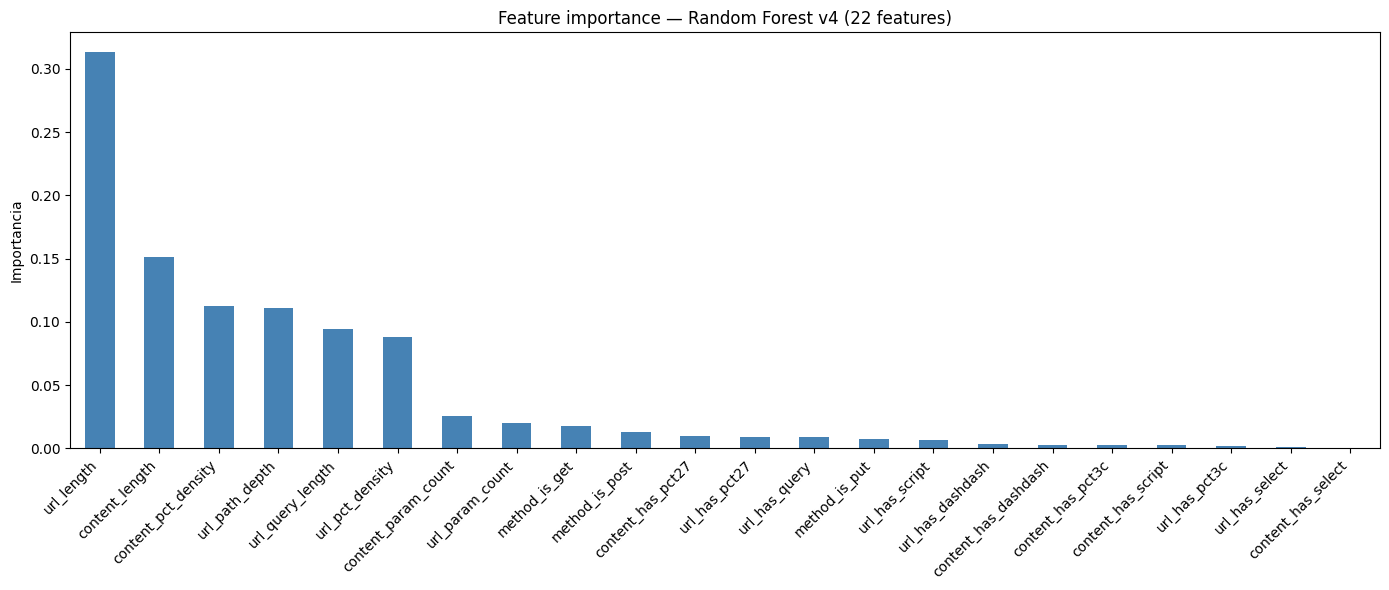

2026/04/13 03:34:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 03:34:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo: Random Forest  [run_id: 718c2229...]
Threshold:  0.1767
ROC-AUC:    0.9605  (v3: 0.950  Δ+0.011)
Recall:     0.9492  (v3: 0.947  Δ+0.002)  ❌
Precision:  0.7793  (v3: 0.716  Δ+0.063)  ❌
F1:         0.8559
FP: 1011  FN: 191  TP: 3569  TN: 4389


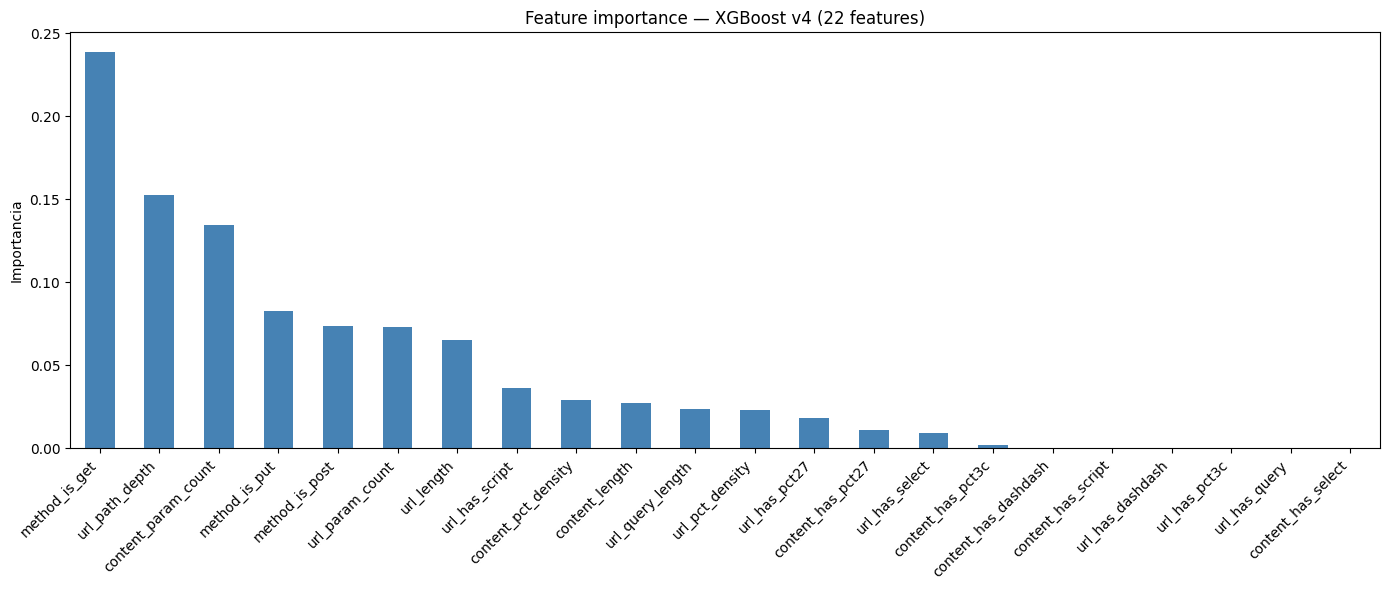

2026/04/13 03:34:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 03:34:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo: XGBoost  [run_id: e37d386d...]
Threshold:  0.2568
ROC-AUC:    0.9635  (v3: 0.948  Δ+0.016)
Recall:     0.9492  (v3: 0.958  Δ-0.009)  ❌
Precision:  0.7928  (v3: 0.649  Δ+0.144)  ❌
F1:         0.8640
FP: 933  FN: 191  TP: 3569  TN: 4467


/Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


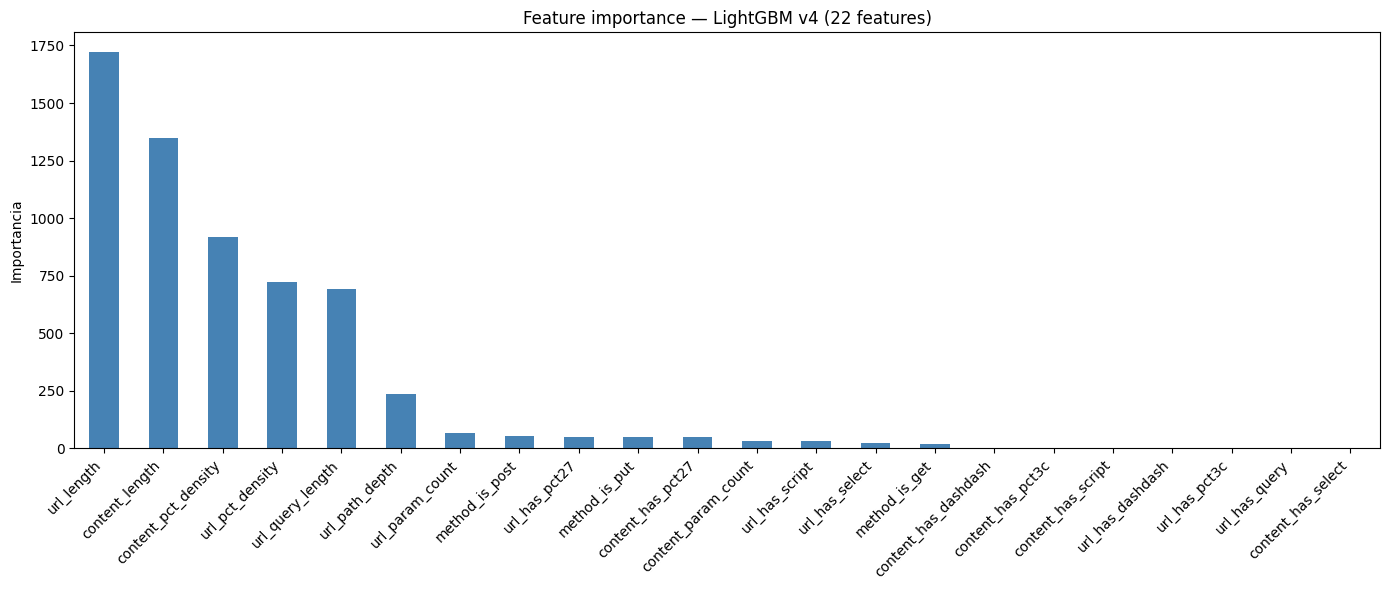

2026/04/13 03:34:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 03:34:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo: LightGBM  [run_id: 3f93d724...]
Threshold:  0.3669
ROC-AUC:    0.9660  (v3: 0.955  Δ+0.011)
Recall:     0.9492  (v3: 0.952  Δ-0.003)  ❌
Precision:  0.8027  (v3: 0.713  Δ+0.090)  ❌
F1:         0.8699
FP: 877  FN: 191  TP: 3569  TN: 4523


In [7]:
def find_best_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    mask = recalls[:-1] >= MIN_RECALL
    if not mask.any():
        best_idx = np.argmax(recalls[:-1])
    else:
        best_idx = np.where(mask, precisions[:-1], 0).argmax()
    return float(thresholds[best_idx])


neg4, pos4 = (y4_train == 0).sum(), (y4_train == 1).sum()
scale4 = neg4 / pos4


def run_model_mlflow(name, model, model_type, params_extra=None):
    run_name = f'model-a-{model_type}-features-v4'

    with mlflow.start_run(run_name=run_name) as run:
        mlflow.log_param('model_type', name)
        mlflow.log_param('dataset', 'csic2010')
        mlflow.log_param('features_version', 'v4')
        mlflow.log_param('n_features', len(feature_names_v4))
        mlflow.log_param('random_state', RANDOM_STATE)
        mlflow.log_param('min_recall_threshold', MIN_RECALL)
        mlflow.log_param('split', '70/15/15')
        if params_extra:
            for k, v in params_extra.items():
                mlflow.log_param(k, v)

        model.fit(X4_train, y4_train)

        val_proba = model.predict_proba(X4_val)[:, 1]
        threshold = find_best_threshold(y4_val, val_proba)

        test_proba = model.predict_proba(X4_test)[:, 1]
        test_pred  = (test_proba >= threshold).astype(int)

        roc  = roc_auc_score(y4_test, test_proba)
        rec  = recall_score(y4_test, test_pred)
        prec = precision_score(y4_test, test_pred)
        f1   = f1_score(y4_test, test_pred)
        cm   = confusion_matrix(y4_test, test_pred)

        mlflow.log_param('threshold', round(float(threshold), 4))
        mlflow.log_metric('roc_auc', round(roc, 4))
        mlflow.log_metric('recall', round(rec, 4))
        mlflow.log_metric('precision', round(prec, 4))
        mlflow.log_metric('f1', round(f1, 4))
        mlflow.log_metric('fp', int(cm[0, 1]))
        mlflow.log_metric('fn', int(cm[1, 0]))
        mlflow.log_metric('tp', int(cm[1, 1]))
        mlflow.log_metric('tn', int(cm[0, 0]))

        if hasattr(model, 'feature_importances_'):
            importances = pd.Series(
                model.feature_importances_, index=feature_names_v4
            ).sort_values(ascending=False)
            fig, ax = plt.subplots(figsize=(14, 6))
            importances.plot(kind='bar', ax=ax, color='steelblue')
            ax.set_title(f'Feature importance — {name} v4 (22 features)')
            ax.set_ylabel('Importancia')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
                plt.savefig(tmp.name, dpi=100)
                mlflow.log_artifact(tmp.name, artifact_path='plots')
            plt.show()
            os.unlink(tmp.name)

        mlflow.sklearn.log_model(model, 'model')
        run_id = run.info.run_id

    v3 = V3_RESULTS.get(name, {})
    print(f'\n{"="*60}')
    print(f'Modelo: {name}  [run_id: {run_id[:8]}...]')
    print(f'{"="*60}')
    print(f'Threshold:  {threshold:.4f}')
    print(f'ROC-AUC:    {roc:.4f}  (v3: {v3.get("roc_auc",0):.3f}  Δ{roc-v3.get("roc_auc",0):+.3f})')
    print(f'Recall:     {rec:.4f}  (v3: {v3.get("recall",0):.3f}  Δ{rec-v3.get("recall",0):+.3f})  {"✅" if rec >= MIN_RECALL else "❌"}')
    print(f'Precision:  {prec:.4f}  (v3: {v3.get("precision",0):.3f}  Δ{prec-v3.get("precision",0):+.3f})  {"✅" if prec >= MIN_PREC else "❌"}')
    print(f'F1:         {f1:.4f}')
    print(f'FP: {int(cm[0,1])}  FN: {int(cm[1,0])}  TP: {int(cm[1,1])}  TN: {int(cm[0,0])}')

    return {'name': name, 'roc_auc': roc, 'recall': rec, 'precision': prec,
            'f1': f1, 'threshold': threshold, 'fp': int(cm[0,1]),
            'fn': int(cm[1,0]), 'run_id': run_id}


results_v4 = []

results_v4.append(run_model_mlflow('Logistic Regression',
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'logreg',
    params_extra={'class_weight': 'balanced', 'max_iter': 1000}))

results_v4.append(run_model_mlflow('Random Forest',
    RandomForestClassifier(n_estimators=200, class_weight='balanced',
                           random_state=RANDOM_STATE, n_jobs=-1),
    'rf',
    params_extra={'n_estimators': 200, 'class_weight': 'balanced'}))

results_v4.append(run_model_mlflow('XGBoost',
    XGBClassifier(n_estimators=200, scale_pos_weight=scale4, eval_metric='logloss',
                  random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'xgboost',
    params_extra={'n_estimators': 200, 'scale_pos_weight': round(scale4, 3)}))

results_v4.append(run_model_mlflow('LightGBM',
    LGBMClassifier(n_estimators=200, scale_pos_weight=scale4,
                   random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    'lgbm',
    params_extra={'n_estimators': 200, 'scale_pos_weight': round(scale4, 3)}))


## 7. Tabla comparativa v3 vs v4


In [8]:
print(f'{'-'*80}')
print(f'{"Modelo":<25} {"ROC-AUC":>10} {"Recall":>10} {"Precision":>10} {"FP":>6} {"Estado":>8}')
print(f'{'-'*80}')
for r in results_v4:
    v3 = V3_RESULTS[r['name']]
    estado = '✅' if r['recall'] >= MIN_RECALL and r['precision'] >= MIN_PREC else '❌'
    print(f'{r["name"]:<25} {r["roc_auc"]:>10.4f} {r["recall"]:>10.4f} {r["precision"]:>10.4f} {r["fp"]:>6} {estado:>8}')
    print(f'{"  vs v3":<25} {r["roc_auc"]-v3["roc_auc"]:>+10.3f} {r["recall"]-v3["recall"]:>+10.3f} {r["precision"]-v3["precision"]:>+10.3f}')
    print()
print(f'{'-'*80}')
print(f'Criterios: Recall >= {MIN_RECALL} | Precision >= {MIN_PREC}')
print()
print('Run IDs en MLflow:')
for r in results_v4:
    print(f'  {r["name"]}: {r["run_id"][:8]}...')


--------------------------------------------------------------------------------
Modelo                       ROC-AUC     Recall  Precision     FP   Estado
--------------------------------------------------------------------------------
Logistic Regression           0.8383     0.9572     0.5104   3452        ❌
  vs v3                       +0.061     -0.020     +0.093

Random Forest                 0.9605     0.9492     0.7793   1011        ❌
  vs v3                       +0.011     +0.002     +0.063

XGBoost                       0.9635     0.9492     0.7928    933        ❌
  vs v3                       +0.016     -0.009     +0.144

LightGBM                      0.9660     0.9492     0.8027    877        ❌
  vs v3                       +0.011     -0.003     +0.090

--------------------------------------------------------------------------------
Criterios: Recall >= 0.95 | Precision >= 0.85

Run IDs en MLflow:
  Logistic Regression: 1e9de44e...
  Random Forest: 718c2229...
  XGBoost: e

## 8. Observaciones

### Resultados v4 vs v3

| Modelo | ROC-AUC | Δv3 | Recall | Δv3 | Precision | Δv3 | FP | Δ FP | Criterios |
|---|---|---|---|---|---|---|---|---|---|
| LR | 0.8383 | +0.061 | 0.9572 ✅ | -0.020 | 0.5104 | +0.093 | 3452 | — | ❌ |
| RF | 0.9605 | +0.011 | **0.9492** | +0.002 | 0.7793 | +0.063 | 1011 | -405 | ❌ Recall < 0.95 |
| XGBoost | 0.9635 | +0.016 | **0.9492** | -0.009 | 0.7928 | **+0.144** | 933 | -511 | ❌ Recall < 0.95 |
| LightGBM | **0.9660** | +0.011 | **0.9492** | -0.003 | **0.8027** | +0.090 | **877** | -567 | ❌ Recall < 0.95 |

Criterios de éxito: Recall ≥ 0.95 **y** Precision ≥ 0.85

### Runs MLflow

| Modelo | Run ID | Run name |
|---|---|---|
| Logistic Regression | `1e9de44e` | `model-a-logreg-features-v4` |
| Random Forest | `718c2229` | `model-a-rf-features-v4` |
| XGBoost | `e37d386d` | `model-a-xgboost-features-v4` |
| LightGBM | `3f93d724` | `model-a-lgbm-features-v4` |

Para ver los runs: `mlflow ui --backend-store-uri "sqlite:///mlflow.db"` desde la raíz → http://localhost:5000 → experimento `mlsec-model-a`

### Análisis de los resultados

**Mayor salto de Precision en todo el proyecto:**
- XGBoost: 0.649 → 0.793 (**+0.144**) — la mayor mejora en una sola iteración
- LightGBM: 0.713 → 0.803 (+0.090) — por primera vez supera 0.80
- El gap restante para LightGBM es **0.803 → 0.85 = 0.047** — el más pequeño hasta ahora

**Techo de ROC-AUC roto:**
- El plateau de ~0.955 que se mantuvo en v1/v2/v3 se rompió: 0.955 → **0.966**
- Las features de estructura de URL aportaron información genuinamente nueva — no solo ruido

**FP cayeron drásticamente:**
- LightGBM: 1444 → 877 (-567) — confirmando que los FP GET eran el cuello de botella
- XGBoost: 1946 → 933 (-1013) — reducción de más del 50%

**Señal en subpoblación GET — las 3 features funcionaron:**
- `url_has_query` correlación +0.341 en GETs (vs +0.175 global) — ataques GET tienen query string más frecuentemente
- `url_path_depth` correlación -0.318 en GETs (vs -0.198 global) — tráfico normal GET tiene paths más profundos
- `url_query_length` correlación +0.297 en GETs (vs +0.178 global) — ataques tienen queries más largas

**Recall 0.9492 — efecto de threshold, no de capacidad del modelo:**
- RF, XGBoost y LightGBM muestran exactamente 0.9492 — 0.0008 por debajo del criterio
- El threshold se optimiza en val; el test set da marginalmente distinto
- ROC-AUC 0.966 confirma que la capacidad de separación es suficiente — es un problema de calibración del threshold, no de información

### Decisión

**v4 valida las 3 features — crear `preprocess_csic_v3.py`** con el set completo de 22 features.

La próxima iteración (v5) arranca desde `features_v3.parquet` y tiene dos objetivos:
1. **Recuperar Recall ≥ 0.95** — ajustar la lógica de threshold o probar `class_weight` más agresivo
2. **Cerrar el gap de Precision 0.047** — LightGBM está en 0.803, target 0.85

Con ROC-AUC 0.966 y Precision 0.803, el modelo tiene la capacidad. El paso siguiente es afinar el threshold y evaluar si hay señal adicional en los 877 FP restantes.

### Advertencias (informativas)

- LightGBM warning de feature names — cosmético, mismo que en versiones anteriores
